<a href="https://colab.research.google.com/github/TerteryanTatev/Decision-Support-and-Expert-Systems/blob/main/Huffman-Data-Compression/huffman_compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Տեքստ › abcbadfa

Տառ | Հավանականություն | Կոդ
--------------------------------
a   | 0.375           | 11
b   | 0.250           | 01
c   | 0.125           | 100
d   | 0.125           | 00
f   | 0.125           | 101

H(p) = 2.1556
L(p) = 2.25
Ստուգում՝ H ≤ L < H+1 → True

Ծառը բացվում է...


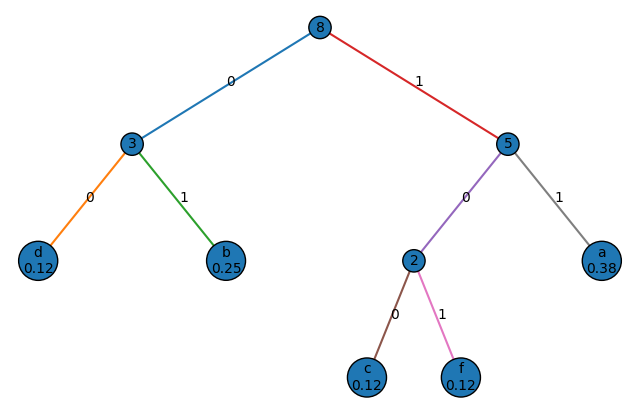

In [ ]:
from collections import Counter
import heapq
import math
import matplotlib.pyplot as plt

class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq


def build_tree(text):
    counts = Counter(text)
    heap = [Node(ch, freq) for ch, freq in counts.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        a = heapq.heappop(heap)
        b = heapq.heappop(heap)

        merged = Node(None, a.freq + b.freq)
        merged.left = a
        merged.right = b

        heapq.heappush(heap, merged)

    return heap[0], counts


def get_codes(node, prefix="", codes=None):
    if codes is None:
        codes = {}

    if node is None:
        return codes

    if node.char is not None:
        codes[node.char] = prefix or "0"
        return codes

    left, right = node.left, node.right

    if left and right and left.freq > right.freq:
        left, right = right, left

    get_codes(left, prefix + "0", codes)
    get_codes(right, prefix + "1", codes)

    return codes


def calculate_entropy(counts, codes, total):
    probs = {ch: cnt / total for ch, cnt in counts.items()}

    H = -sum(p * math.log2(p) for p in probs.values())
    L = sum(len(codes[ch]) * probs[ch] for ch in probs)

    return probs, H, L


# ── Draw Tree ────────────────────────────────────────
def draw_tree(node, x=0, y=0, dx=1.5, pos=None, edges=None):
    if pos is None:
        pos = {}
    if edges is None:
        edges = []

    pos[id(node)] = (x, y)

    if node.left:
        edges.append((node, node.left, "0"))
        draw_tree(node.left, x - dx, y - 1, dx / 2, pos, edges)

    if node.right:
        edges.append((node, node.right, "1"))
        draw_tree(node.right, x + dx, y - 1, dx / 2, pos, edges)

    return pos, edges


def find_node(node, target_id):
    if id(node) == target_id:
        return node
    if node.left:
        res = find_node(node.left, target_id)
        if res:
            return res
    if node.right:
        res = find_node(node.right, target_id)
        if res:
            return res
    return None


def plot_tree(root, probs):
    pos, edges = draw_tree(root)

    plt.figure(figsize=(8, 5))

    for parent, child, label in edges:
        x1, y1 = pos[id(parent)]
        x2, y2 = pos[id(child)]

        plt.plot([x1, x2], [y1, y2])
        plt.text((x1+x2)/2, (y1+y2)/2, label)

    for node_id, (x, y) in pos.items():
        node = find_node(root, node_id)

        if node.char:
            label = f"{node.char}\n{probs[node.char]:.2f}"
        else:
            label = str(node.freq)

        plt.text(x, y, label,
                 ha='center', va='center',
                 bbox=dict(boxstyle="circle"))

    plt.axis("off")
    plt.show()


text = input("Տեքստ › ") or "տետր"

root, counts = build_tree(text)
codes = get_codes(root)
total = len(text)

probs, H, L = calculate_entropy(counts, codes, total)

print("\nՏառ | Հավանականություն | Կոդ")
print("--------------------------------")
for ch in counts:
    print(f"{ch}   | {probs[ch]:.3f}           | {codes[ch]}")

print("\nH(p) =", round(H, 4))
print("L(p) =", round(L, 4))
print("Ստուգում՝ H ≤ L < H+1 →", H <= L < H + 1)

print("\nԾառը բացվում է...")
plot_tree(root, probs)

Տեքստ › abacabd

Աղյուսակ
  Տառ       P  Կոդ  Երկարություն
0   a  0.4286    1             1
1   b  0.2857   01             2
2   c  0.1429  001             3
3   d  0.1429  000             3

Encoded: 1011001101000
Decoded ճիշտ է → True

H = 1.8424
L = 1.8571
Efficiency = 0.992
H ≤ L < H+1 → True


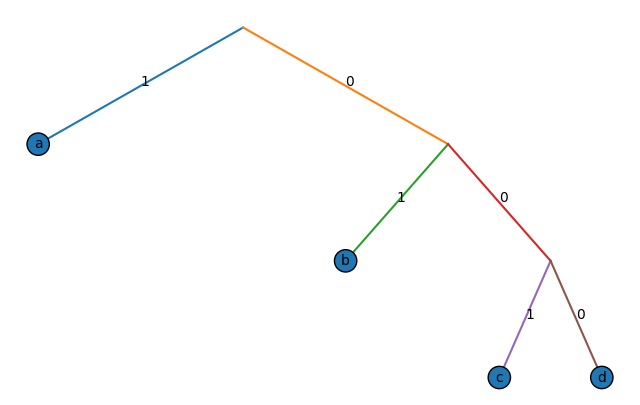

In [ ]:
from collections import Counter
import math
import matplotlib.pyplot as plt
import pandas as pd


class Node:
    def __init__(self, symbols):
        self.symbols = symbols
        self.left = None
        self.right = None


def build_tree(symbols):
    if len(symbols) == 1:
        return Node(symbols)

    total = sum(p for _, p in symbols)

    acc = 0
    best_idx = 0
    min_diff = float("inf")

    for i in range(len(symbols)):
        acc += symbols[i][1]
        diff = abs(total/2 - acc)
        if diff < min_diff:
            min_diff = diff
            best_idx = i

    node = Node(symbols)
    node.left = build_tree(symbols[:best_idx + 1])
    node.right = build_tree(symbols[best_idx + 1:])

    return node


def generate_codes(node, prefix="", codes=None):
    if codes is None:
        codes = {}

    if node.left is None and node.right is None:
        ch = node.symbols[0][0]
        codes[ch] = prefix if prefix else "0"
        return codes

    if node.left:
        generate_codes(node.left, prefix + "1", codes)

    if node.right:
        generate_codes(node.right, prefix + "0", codes)

    return codes


def encode(text, codes):
    return "".join(codes[ch] for ch in text)


def decode(encoded, root):
    res = ""
    node = root

    for bit in encoded:
        node = node.left if bit == "1" else node.right

        if node.left is None and node.right is None:
            res += node.symbols[0][0]
            node = root

    return res


# ── Metrics ────────────────────────────────────────
def calc_metrics(text, codes):
    counts = Counter(text)
    total = len(text)

    probs = {ch: cnt/total for ch, cnt in counts.items()}

    H = -sum(p * math.log2(p) for p in probs.values())
    L = sum(len(codes[ch]) * probs[ch] for ch in probs)

    return probs, H, L


# ── Table ──────────────────────────────────────────
def build_table(probs, codes):
    data = []

    for ch in sorted(probs):
        data.append([
            ch,
            round(probs[ch], 4),
            codes[ch],
            len(codes[ch])
        ])

    df = pd.DataFrame(data, columns=["Տառ", "P", "Կոդ", "Երկարություն"])
    return df


# ── Draw tree ──────────────────────────────────────
def draw(node, x=0, y=0, dx=1.5, pos=None, edges=None):
    if pos is None:
        pos = {}
    if edges is None:
        edges = []

    pos[node] = (x, y)

    if node.left:
        edges.append((node, node.left, "1"))
        draw(node.left, x - dx, y - 1, dx/2, pos, edges)

    if node.right:
        edges.append((node, node.right, "0"))
        draw(node.right, x + dx, y - 1, dx/2, pos, edges)

    return pos, edges


def plot_tree(root):
    pos, edges = draw(root)

    plt.figure(figsize=(8, 5))

    for p, c, l in edges:
        x1, y1 = pos[p]
        x2, y2 = pos[c]

        plt.plot([x1, x2], [y1, y2])
        plt.text((x1+x2)/2, (y1+y2)/2, l)

    for node, (x, y) in pos.items():
        if node.left is None and node.right is None:
            label = node.symbols[0][0]
        else:
            label = ""

        plt.text(x, y, label,
                 ha="center", va="center",
                 bbox=dict(boxstyle="circle"))

    plt.axis("off")
    plt.show()


text = input("Տեքստ › ") or "տետր"

counts = Counter(text)
total = len(text)

probs_list = [(ch, cnt/total) for ch, cnt in counts.items()]
probs_list.sort(key=lambda x: (-x[1], x[0]))

root = build_tree(probs_list)
codes = generate_codes(root)

encoded = encode(text, codes)
decoded = decode(encoded, root)

probs, H, L = calc_metrics(text, codes)
eff = H / L if L > 0 else 0

table = build_table(probs, codes)

print("\nԱղյուսակ")
print(table)

print("\nEncoded:", encoded)
print("Decoded ճիշտ է →", decoded == text)

print("\nH =", round(H, 4))
print("L =", round(L, 4))
print("Efficiency =", round(eff, 4))
print("H ≤ L < H+1 →", H <= L < H + 1)

# tree plot
plot_tree(root)